# PROJECT : HOUSE PRICE PREDICTION

## GOAL : Predict price using house features like area, bedrooms, bathrooms, parking, furnishing, etc.

**STEP 1: IMPORT NECESSARY LIBRARIES AND LOAD DATASET**

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures,OrdinalEncoder,StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_squared_error

df=pd.read_csv("C:\\Users\\Lenovo\\Downloads\\House price\\Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


**STEP 2: UNDERSTAND DATASET**

In [52]:
df.shape

(545, 13)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Some columns are object type. These must be converted before regression. Because regression only accepts numbers.

**STEP 3: CHECK MISSING VALUES**

In [31]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**STEP 4: SEPARATE X AND y**

Since our goal (target) is to predict house price, set y as price.

In [56]:
#FEATURES
X=df.drop('price',axis=1)
y=df['price']

**STEP 5: CONVERT CATEGORICAL COLUMNS**

In [57]:
# X=pd.get_dummies(X,drop_first=True)
# X
binary_cols=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    X[col]=X[col].map({'yes':1,'no':0})
#Ordinal encoding
furnish_order=['unfurnished','semi-furnished','furnished']
encoder=OrdinalEncoder(categories=[furnish_order])
X[['furnishingstatus']]=encoder.fit_transform(X[['furnishingstatus']])
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,2.0
1,8960,4,4,4,1,0,0,0,1,3,0,2.0
2,9960,3,2,2,1,0,1,0,0,2,1,1.0
3,7500,4,2,2,1,0,1,0,1,3,1,2.0
4,7420,4,1,2,1,1,1,0,1,2,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,0.0
541,2400,3,1,1,0,0,0,0,0,0,0,1.0
542,3620,2,1,1,1,0,0,0,0,0,0,0.0
543,2910,3,1,1,0,0,0,0,0,0,0,2.0


**STEP 6: TRAIN-TEST SPLIT**

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**STEP 7: SCALING**

In [59]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

**STEP 8: START WITH LINEAR REGRESSION BASELINE**

In [60]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)
print("m:",model.coef_)
print("c:",model.intercept_)

m: [519288.13010471  58690.91849754 523153.38284253 348177.1136099
 128115.92797751  89357.64620755 188462.04856579 150570.02827934
 362446.18646599 192786.98589143 266661.04914928 158183.27016874]
c: 4706527.385321101


**STEP 9: PREDICT**

In [62]:
y_predict=model.predict(X_test_scaled)

**STEP 10: EVALUATE**

In [63]:
print("R2 score:",r2_score(y_test,y_predict))
print("MSE:",mean_squared_error(y_test,y_predict))

R2 score: 0.6494754192267794
MSE: 1771751116594.0398


**STEP 12: TRY RIDGE AND LASSO AND EVALUATE**

In [74]:
ridge=Ridge(alpha=10)
ridge.fit(X_train_scaled,y_train)

ridge_predict=ridge.predict(X_test_scaled)
print("R2 score:",r2_score(y_test,ridge_predict))
print("MSE:",mean_squared_error(y_test,ridge_predict))

R2 score: 0.6482230712909262
MSE: 1778081197208.6938


In [75]:
lasso=Lasso(alpha=1000)
lasso.fit(X_train_scaled,y_train)

lasso_predict=lasso.predict(X_test_scaled)
print("R2 score:",r2_score(y_test,lasso_predict))
print("MSE:",mean_squared_error(y_test,lasso_predict))

R2 score: 0.6491195929045552
MSE: 1773549665735.2256


**STEP 13: COMPARE ALL MODELS**

In [82]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'R2 Score': [
        r2_score(y_test, y_predict),
        r2_score(y_test, ridge_predict),
        r2_score(y_test, lasso_predict)
    ],
    'MSE': [
        mean_squared_error(y_test, y_predict),
        mean_squared_error(y_test, ridge_predict),
        mean_squared_error(y_test, lasso_predict)
    ]
})

print(results)

               Model  R2 Score           MSE
0  Linear Regression  0.649475  1.771751e+12
1              Ridge  0.648223  1.778081e+12
2              Lasso  0.649120  1.773550e+12


**STEP 14: CHECK COEFFICIENTS**

In [83]:
print("Linear Coefficients:")
pd.Series(model.coef_, index=X.columns)

Linear Coefficients:


area                519288.130105
bedrooms             58690.918498
bathrooms           523153.382843
stories             348177.113610
mainroad            128115.927978
guestroom            89357.646208
basement            188462.048566
hotwaterheating     150570.028279
airconditioning     362446.186466
parking             192786.985891
prefarea            266661.049149
furnishingstatus    158183.270169
dtype: float64

In [79]:
print("Ridge Coefficients:")
pd.Series(ridge.coef_, index=X.columns)

Ridge Coefficients:


area                509061.140764
bedrooms             66823.997804
bathrooms           513422.369608
stories             340655.295382
mainroad            130513.479147
guestroom            92735.533934
basement            183136.565789
hotwaterheating     146918.050376
airconditioning     358618.885812
parking             193913.977815
prefarea            262278.195853
furnishingstatus    158363.139879
dtype: float64

In [80]:
print("Lasso Coefficients:")
pd.Series(lasso.coef_, index=X.columns)

Lasso Coefficients:


area                519020.159368
bedrooms             58407.699350
bathrooms           522885.527508
stories             347573.588634
mainroad            127654.183430
guestroom            88981.765432
basement            187831.614023
hotwaterheating     149537.340212
airconditioning     362055.639251
parking             192395.737259
prefarea            266102.805370
furnishingstatus    157806.447314
dtype: float64

**STEP 15: ACTUAL VS PREDICTED PLOT**

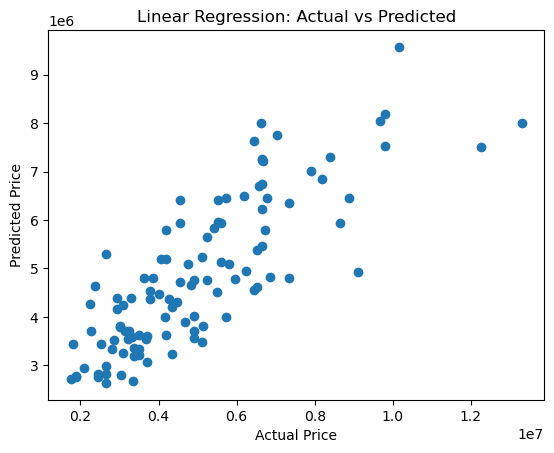

In [84]:
plt.scatter(y_test,y_predict)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

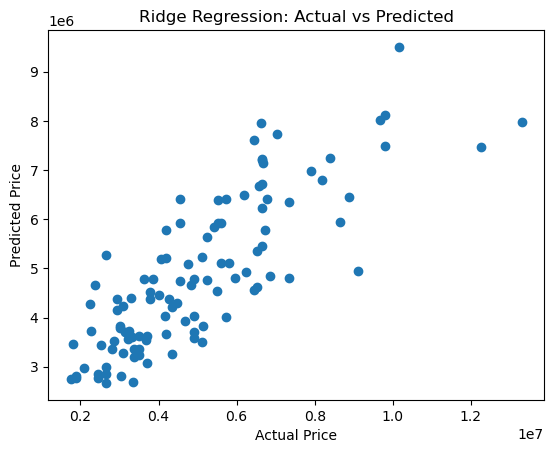

In [87]:
plt.scatter(y_test, ridge_predict)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

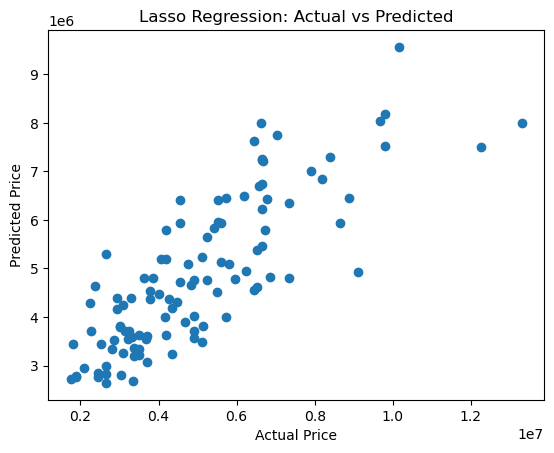

In [86]:
plt.scatter(y_test, lasso_predict)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()

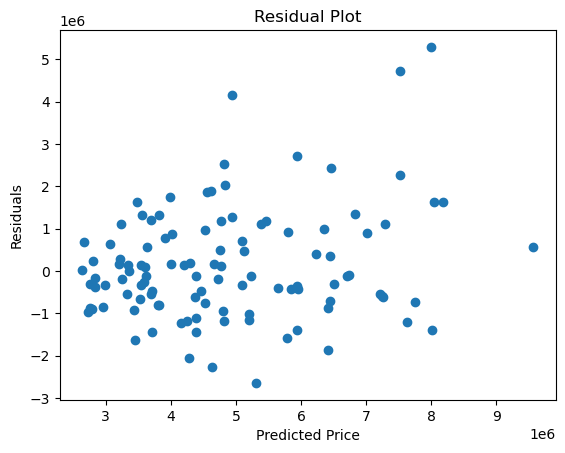